# Análisis exploratorio de datos

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.float_format = '{:.2f}'.format

df = pd.read_csv('../data/interim/df_merged.csv')

## 1. Análisis inicial

In [15]:
df.shape

(36059, 11)

In [16]:
df.head()

,años_experiencia,experiencia,modalidad,formación_académica,sector,tipo_de_empleo,beneficios,Ciudad,Salario_medio,Rango_Salarial,id
0,3.00,junior,Presencial,Grado Universitario,"Salud, Farmacia y Tecnología Médica",Media jornada,NaN,Madrid,25000.00,22.000-30.000,0
1,2.00,junior,Presencial,Ninguna,Servicios,Jornada completa,NaN,Madrid,43200.00,40.000-52.000,1
2,1.00,junior,Presencial,Grado Universitario,Economía y política,Jornada completa,NaN,Madrid,13200.00,<15.000,2
3,3.00,senior,NaN,Ninguna,Transporte y Logística,NaN,NaN,Madrid,131112.00,100.000-150.000,3
4,0.00,intern,Presencial,Ninguna,Economía y política,Jornada completa,NaN,Madrid,15144.00,15.000-22.000,4


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36059 entries, 0 to 36058
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   años_experiencia     18657 non-null  float64
 1   experiencia          19933 non-null  object 
 2   modalidad            9665 non-null   object 
 3   formación_académica  36059 non-null  object 
 4   sector               36059 non-null  object 
 5   tipo_de_empleo       19988 non-null  object 
 6   beneficios           324 non-null    object 
 7   Ciudad               32133 non-null  object 
 8   Salario_medio        20075 non-null  float64
 9   Rango_Salarial       19982 non-null  object 
 10  id                   36059 non-null  int64  
dtypes: float64(2), int64(1), object(8)
memory usage: 3.0+ MB


La variable beneficios no tiene ningun valor ya que casi todos los datos son nulos. La variable modalidad tampoco aporta mucho valor y tiene demasiados nulos.

In [5]:
df.drop(columns=['modalidad','beneficios'], inplace=True)

In [6]:
df['Rango_Salarial'].value_counts()

Rango_Salarial
65.000-80.000      3788
<15.000            3435
15.000-22.000      2873
80.000-100.000     2295
30.000-40.000      2027
22.000-30.000      1967
40.000-52.000      1243
100.000-150.000    1177
52.000-65.000       992
>150.000            185
Name: count, dtype: int64

## 2. Análisis variables numéricas

In [ ]:
numericas = df.select_dtypes(include=np.number).columns.tolist()
numericas.remove('id')

In [10]:
df[numericas].describe()

,años_experiencia,Salario_medio
count,18657.00,20075.00
mean,1.79,54386.50
std,2.22,258424.47
min,0.00,0.00
25%,0.00,18720.00
50%,1.00,38000.00
75%,3.00,80000.00
max,30.00,36000000.00


Un salario máximo de 36.000.000 o uno mínimo de 0 son outliers claros.

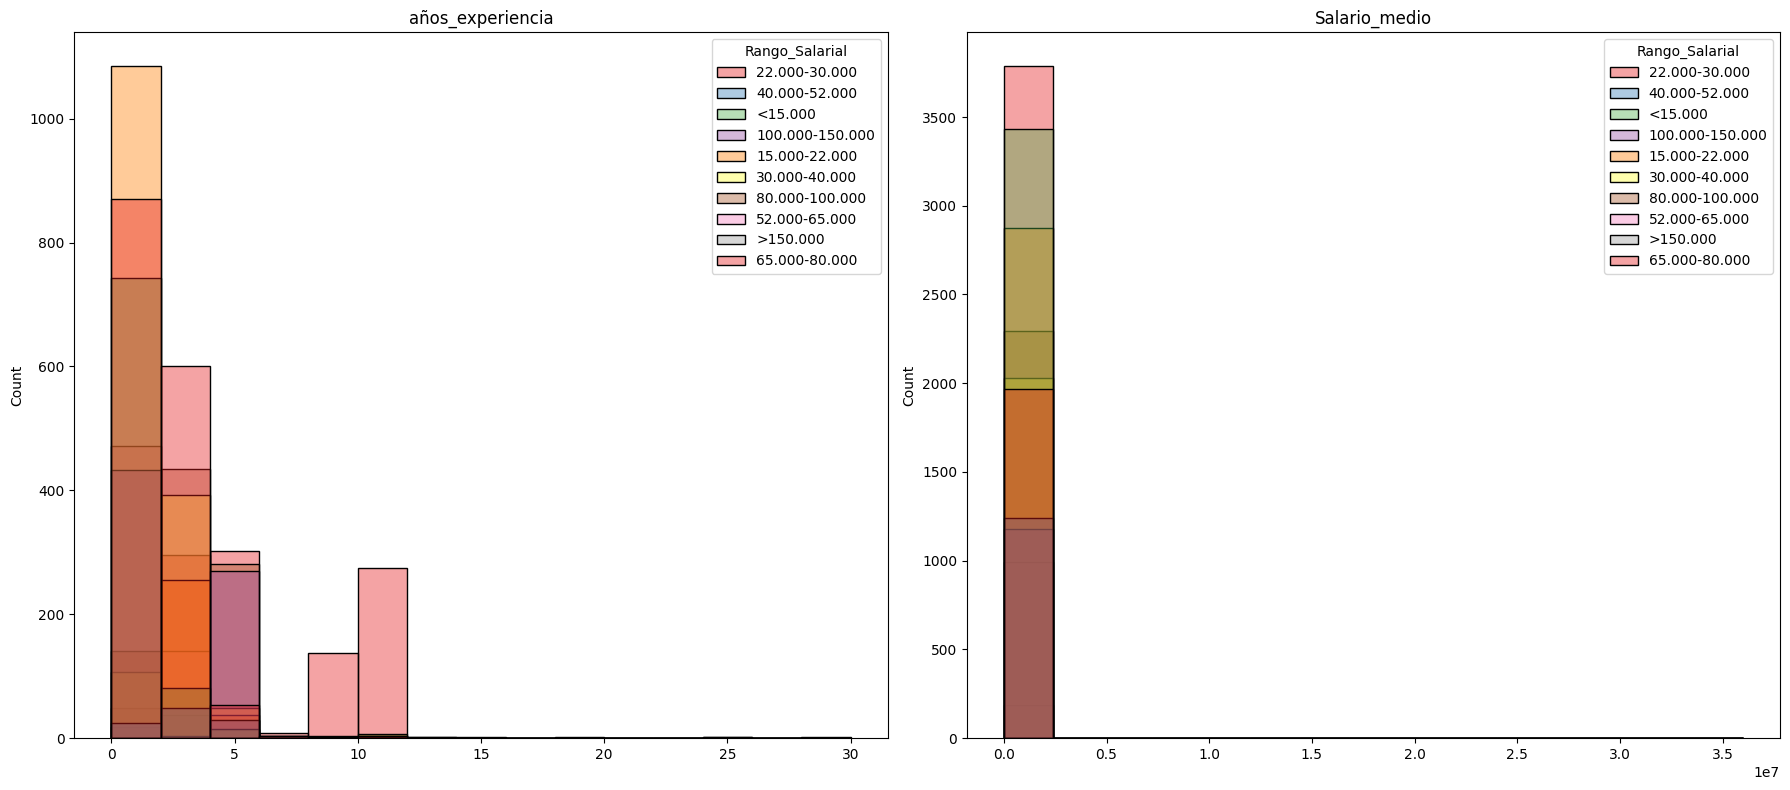

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.histplot(
        data= df,
        x = col,
        hue='Rango_Salarial',
        bins=15,
        ax=axes[i],
        alpha=0.4,
        palette='Set1'
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

Aunque hay muchas categorías y los colores no son claros, se puede ver como las personas con más años de experiencia tienen un salario alto (65-80), y las personas con salario bajo (15-22) son la mayoría con poca experiencia.

### Correlación

<Axes: >

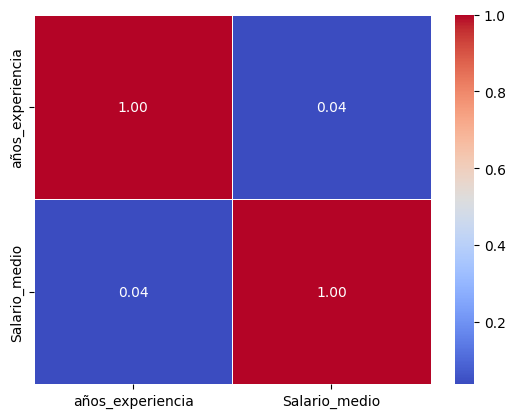

In [12]:
sns.heatmap(df[numericas].corr(), annot=True, cmap='coolwarm', linewidths=0.5, linecolor='white', fmt='.2f')

<Axes: >

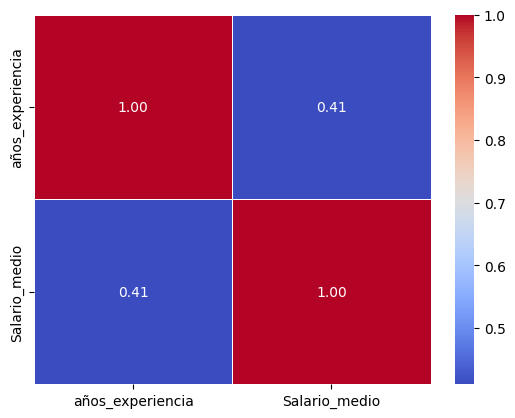

In [13]:
sns.heatmap(df[numericas].corr(method='spearman'), annot=True, cmap='coolwarm', linewidths=0.5, linecolor='white', fmt='.2f')

La experiencia no tiene mucha con el salario. He puesto el método spearman para captar relaciones monótonas.

### Valores atípicos

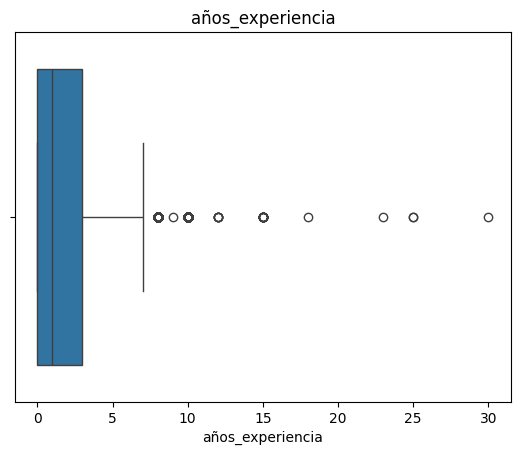

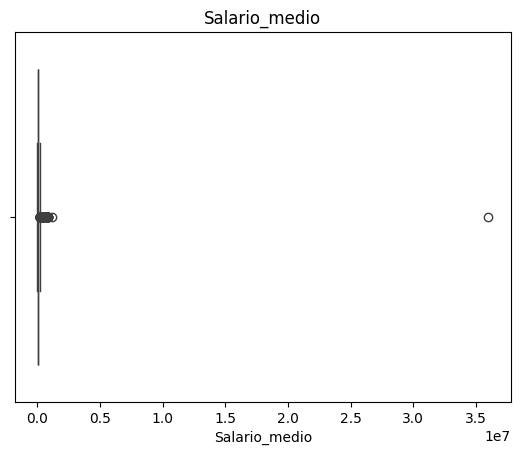

In [ ]:
for col in numericas:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

<Axes: xlabel='Salario_medio'>

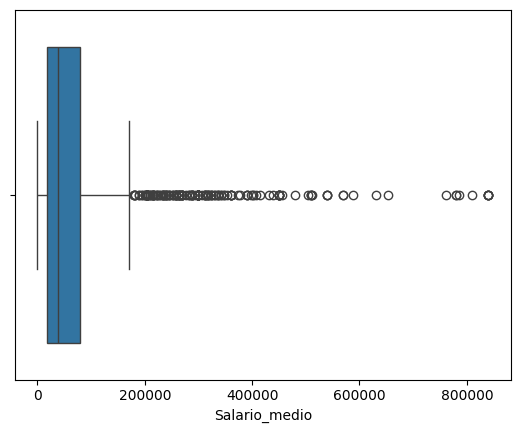

In [36]:
sns.boxplot(x=df[df['Salario_medio'] < 1000000]['Salario_medio'])

In [37]:
df[df['Salario_medio'] < 200000].shape

(19905, 10)

Por suerte, el número de outliers es bajo y me puedo permitir eliminarlos directamente.

## 3. Análisis variables categóricas

In [ ]:
categorical = df.select_dtypes(include='object').columns.tolist()
categorical.remove('Titulo') #por ahora no me sirven ambas
categorical.remove('habilidades')

In [49]:
categorical

['experiencia',
 'formación_académica',
 'sector',
 'tipo_de_empleo',
 'Ciudad',
 'Rango_Salarial']

### Experiencia

In [50]:
df['experiencia'].value_counts()

experiencia
junior    7176
intern    6831
senior    5926
Name: count, dtype: int64

In [53]:
df['experiencia'].notna().sum()

19933

In [78]:
df[df['experiencia'] == 'intern']['Rango_Salarial'].value_counts()  


Rango_Salarial
15.000-22.000      591
<15.000            505
52.000-65.000      470
22.000-30.000      463
100.000-150.000    433
80.000-100.000     143
30.000-40.000       58
>150.000            23
65.000-80.000       15
40.000-52.000        9
Name: count, dtype: int64

In [81]:
df[df['experiencia'] == 'junior']['Rango_Salarial'].value_counts()  


Rango_Salarial
22.000-30.000      899
15.000-22.000      695
30.000-40.000      387
<15.000            265
65.000-80.000      169
>150.000            49
40.000-52.000       37
52.000-65.000       10
80.000-100.000       3
100.000-150.000      2
Name: count, dtype: int64

In [82]:
df[df['experiencia'] == 'senior']['Rango_Salarial'].value_counts()  

Rango_Salarial
65.000-80.000      1392
80.000-100.000     1115
100.000-150.000     286
22.000-30.000       181
52.000-65.000       168
30.000-40.000       123
15.000-22.000       109
<15.000              77
40.000-52.000        67
>150.000             36
Name: count, dtype: int64

### Formación académica

In [83]:
df['formación_académica'].value_counts()

formación_académica
Ninguna                23836
Grado Universitario     6304
FP Superior             3328
ESO                     1106
FP Medio                1009
Postgrado                476
Name: count, dtype: int64

In [84]:
df[df['formación_académica'] == 'Ninguna']['Rango_Salarial'].value_counts()  

Rango_Salarial
65.000-80.000      3351
<15.000            3063
15.000-22.000      2116
80.000-100.000     2111
30.000-40.000      1648
40.000-52.000      1177
100.000-150.000     895
22.000-30.000       893
52.000-65.000       826
>150.000             95
Name: count, dtype: int64

In [85]:
df[df['formación_académica'] == 'Grado Universitario']['Rango_Salarial'].value_counts() 

Rango_Salarial
22.000-30.000      595
30.000-40.000      291
100.000-150.000    277
80.000-100.000     182
<15.000            176
15.000-22.000      162
52.000-65.000      159
65.000-80.000       75
>150.000            66
40.000-52.000       55
Name: count, dtype: int64

In [86]:
df[df['formación_académica'] == 'ESO']['Rango_Salarial'].value_counts() 

Rango_Salarial
22.000-30.000      145
15.000-22.000      105
<15.000             61
30.000-40.000        3
100.000-150.000      2
40.000-52.000        1
52.000-65.000        1
>150.000             1
Name: count, dtype: int64

### Sector

In [87]:
df['sector'].value_counts()

sector
Servicios                              7989
Tecnología y telecomunicaciones        7032
Construcción                           3098
Internet                               2795
Comercio minorista y comercio          2698
Transporte y Logística                 2337
Salud, Farmacia y Tecnología Médica    2037
Deportes y recreación                  1542
Comercio electrónico                    959
Energía y medio ambiente                957
Economía y política                     954
Agricultura                             811
Finanzas y seguros                      782
Productos químicos y recursos           699
Medios de comunicación                  412
Bienes de consumo                       347
Metales y electrónica                   312
Viajes, turismo y hostelería            152
Publicidad y Marketing                  105
Sociedad                                 38
Bienes raíces                             3
Name: count, dtype: int64

### Tipo de empleo

In [89]:
df['tipo_de_empleo'].value_counts()

tipo_de_empleo
Jornada completa     10916
Temporal              4411
Media jornada         2890
Contrato por obra      928
Prácticas              714
Otro                   125
Voluntariado             4
Name: count, dtype: int64

El voluntariado es una muestra muy baja, lo voy a agregar a la categoría Otro.

In [98]:
df.loc[df['tipo_de_empleo'] == 'Voluntariado', 'tipo_de_empleo'] = 'Otro'

In [90]:
df[df['tipo_de_empleo'] == 'Jornada completa']['Rango_Salarial'].value_counts()

Rango_Salarial
15.000-22.000      1231
22.000-30.000       921
<15.000             579
65.000-80.000       361
30.000-40.000       310
>150.000            147
80.000-100.000      144
40.000-52.000        90
52.000-65.000        57
100.000-150.000      12
Name: count, dtype: int64

In [93]:
df[df['tipo_de_empleo'] == 'Prácticas']['Rango_Salarial'].value_counts()

Rango_Salarial
<15.000            85
30.000-40.000      14
52.000-65.000       7
40.000-52.000       6
>150.000            6
15.000-22.000       5
100.000-150.000     5
22.000-30.000       5
80.000-100.000      4
65.000-80.000       3
Name: count, dtype: int64

### Ciudad

In [100]:
df['Ciudad'].value_counts()

Ciudad
Madrid                        6012
Barcelona                     2491
España                        2237
Zaragoza                      1214
Valencia                      1100
Pontevedra                     931
Alicante                       909
Málaga                         831
Bilbao                         810
Logroño                        663
Toledo                         658
Sevilla                        629
Girona                         613
Tarragona                      610
Santander                      601
Vigo                           570
Palma de Mallorca              556
Jerez de la Frontera           542
Pamplona                       536
Santa Cruz de Tenerife         520
Gijón                          515
Murcia                         510
Almería                        497
Huesca                         493
Guadalajara                    440
Castellón de la Plana          435
Lugo                           414
Jaén                           390
Córdoba      